In [1]:
from pathlib import Path
import random
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import wfdb
from functools import lru_cache


ROOT = Path("/data/ahmed/icentia11k")

# Key hyperparams (you can change later)
FS = 250                 # keep native Icentia sampling rate (recommended)

WINDOW_SEC = 60
WINDOW_SAMPLES = FS * WINDOW_SEC
POS_PER_PATIENT = 2      # two windows per patient per __getitem__

RNG = np.random.default_rng(42)


In [2]:
def list_patients(root: Path):
    # patient folders like p00/p00000
    patients = []
    for sub in sorted(root.glob("p*/p*")):
        if sub.is_dir() and sub.name.startswith("p"):
            patients.append(sub)
    return patients

def list_record_bases(patient_dir: Path):
    heads = sorted(patient_dir.glob("*.hea"))
    recs = []
    for h in heads:
        base = h.with_suffix("")
        if base.with_suffix(".dat").exists() and base.with_suffix(".atr").exists():
            recs.append(base)
    return recs


patients = list_patients(ROOT)
print("num patients:", len(patients))
print("example:", patients[0], "records:", len(list_record_bases(patients[0])))


num patients: 11000
example: /data/ahmed/icentia11k/p00/p00000 records: 50


In [3]:
import os
from tqdm import tqdm

def preprocess_to_memmap(patient_dirs, save_root, fs=250):
    save_root = Path(save_root)
    os.makedirs(save_root, exist_ok=True)
    
    # Define filter once
    lowcut, highcut = 0.5, 40.0
    nyq = 0.5 * fs
    b, a = scipy.signal.butter(4, [lowcut/nyq, highcut/nyq], btype='bandpass')

    print(f"Preprocessing {len(patient_dirs)} patients...")
    for pd in tqdm(patient_dirs):
        # Create subfolders like p00/p00001
        rel_path = pd.relative_to(ROOT)
        (save_root / rel_path).mkdir(parents=True, exist_ok=True)
        
        recs = list_record_bases(pd)
        for rec in recs:
            save_path = save_root / rel_path / f"{rec.name}_filtered.npy"
            
            # Skip if already processed
            if save_path.exists():
                continue
                
            try:
                # Load and Filter
                sig, _ = wfdb.rdsamp(str(rec))
                sig = sig[:, 0].astype(np.float32) if sig.ndim == 2 else sig.squeeze().astype(np.float32)
                sig = scipy.signal.filtfilt(b, a, sig).astype(np.float32)
                
                # Save as raw numpy array
                np.save(str(save_path), sig)
            except Exception as e:
                print(f"Error processing {rec}: {e}")

# Run this once!
PROCESSED_ROOT = "/data/ahmed/icentia_processed"
# preprocess_to_memmap(patients, PROCESSED_ROOT)

In [4]:
RHY_MAP = {
    "N": "N",
    "AFIB": "AFIB",
    "AFL": "AFL",
    "AFLUT": "AFL",      # if present
    "AFLUTTER": "AFL",   # if present
}

def normalize_rhythm_token(tok: str):
    tok = tok.strip().upper()
    tok = tok.replace("(", "").replace(")", "").strip()
    # e.g. "(N" -> "N", "(AFIB" -> "AFIB"
    return RHY_MAP.get(tok, None)

def build_rhythm_intervals_from_ann(ann, sig_len: int):
    """
    Parse WFDB rhythm annotations into non-overlapping labeled intervals.

    Behavior:
    - On "(LABEL": opens a segment at sample s.
      If a segment is already open, it is FORCE-CLOSED at s (new segment boundary).
    - On ")": closes the current segment at sample s (if open).
    - At end of annotation stream: closes any open segment at last annotation sample.

    Returns: list of (start, end, label) in samples, with end > start.
    """
    intervals = []
    cur_label = None
    cur_start = None

    def close_at(end_s: int):
        nonlocal cur_label, cur_start, intervals
        if cur_start is not None and cur_label is not None and end_s is not None and end_s > cur_start:
            intervals.append((int(cur_start), int(end_s), cur_label))
        cur_label = None
        cur_start = None

    for s, note in zip(ann.sample, ann.aux_note):
        if note is None:
            continue
        note = str(note).strip()
        if note == "" or note.upper() == "NONE":
            continue
        s = int(s)
        note = note.strip()

        if note.startswith("("):
            # Force-close prior segment at the boundary (even if the new token is unknown)
            if cur_start is not None:
                close_at(s)

            lab = normalize_rhythm_token(note)
            if lab is not None:
                cur_label = lab
                cur_start = s
            else:
                # Unknown rhythm start token: treat as boundary but do not open a labeled segment
                print("Warning: unknown rhythm token", note)
                cur_label = None
                cur_start = None

        elif note.startswith(")"):
            # Close current segment at s (if open)
            close_at(s)

    # Close any dangling open segment
    if cur_start is not None and cur_label is not None and len(ann.sample) > 0:
        close_at(sig_len)

    return intervals



In [5]:
def label_window_by_occupancy(intervals, w_start, w_end, thresh=0.6):
    """
    intervals: list of (start, end, label) in samples
    window: [w_start, w_end)
    """
    dur = w_end - w_start
    if dur <= 0:
        return None

    occ = {"AFIB": 0, "AFL": 0}  # N is default remainder
    for a, b, lab in intervals:
        if b <= w_start or a >= w_end:
            continue
        overlap = max(0, min(b, w_end) - max(a, w_start))
        if lab in occ:
            occ[lab] += overlap

    if occ["AFIB"] / dur >= thresh:
        return "AFIB"
    if occ["AFL"] / dur >= thresh:
        return "AFL"
    return "N"


In [6]:
import numpy as np
import scipy.signal

class ECGAugment:
    """
    Realistic ECG augmentations for contrastive / masked pretraining.
    Designed to avoid shortcut cues (e.g., hard zeros) and preserve morphology.
    """

    def __init__(
        self,
        fs: int = 250,

        # Gain / noise
        p_scale: float = 1.0,
        scale_min: float = 0.90,
        scale_max: float = 1.10,

        p_white_noise: float = 1.0,
        white_noise_std: float = 0.005,   # relative to signal units; tune after inspecting amplitude

        # Baseline wander (low-frequency drift)
        p_baseline: float = 0.7,
        baseline_amp: float = 0.10,       # as fraction of signal std
        baseline_f_lo: float = 0.05,      # Hz
        baseline_f_hi: float = 0.50,      # Hz

        # EMG-like noise (higher frequency)
        p_emg: float = 0.5,
        emg_std: float = 0.01,            # as fraction of signal std

        # Smooth masking (structured dropout)
        p_mask: float = 0.5,
        n_masks_min: int = 0,
        n_masks_max: int = 1,
        mask_len_min_sec: float = 0.10,
        mask_len_max_sec: float = 0.50,
        mask_depth_min: float = 0.7,      # 0.7 means keep 30% during mask
        mask_depth_max: float = 1.0,      # 1.0 means fully suppressed (but still smooth edges)

        # RNG
        seed: int | None = None,
    ):
        self.fs = fs

        self.p_scale = p_scale
        self.scale_min = scale_min
        self.scale_max = scale_max

        self.p_white_noise = p_white_noise
        self.white_noise_std = white_noise_std

        self.p_baseline = p_baseline
        self.baseline_amp = baseline_amp
        self.baseline_f_lo = baseline_f_lo
        self.baseline_f_hi = baseline_f_hi

        self.p_emg = p_emg
        self.emg_std = emg_std

        self.p_mask = p_mask
        self.n_masks_min = n_masks_min
        self.n_masks_max = n_masks_max
        self.mask_len_min = int(mask_len_min_sec * fs)
        self.mask_len_max = int(mask_len_max_sec * fs)
        self.mask_depth_min = mask_depth_min
        self.mask_depth_max = mask_depth_max

        self.rng = np.random.default_rng(seed)
        

    def _as_2d(self, x: np.ndarray) -> tuple[np.ndarray, bool]:
        """Return (y[T,C], was_1d)."""
        if x.ndim == 1:
            return x[:, None], True
        return x, False

    def _smooth_mask(self, T: int, start: int, m: int, depth: float) -> np.ndarray:
        """
        Create multiplicative mask of length T with a smooth window on [start, start+m).
        depth in [0,1]: depth=1 -> fully suppressed region, depth=0 -> no suppression.
        We implement a raised-cosine fade.
        """
        mask = np.ones((T,), dtype=np.float32)
        end = min(T, start + m)
        m_eff = end - start
        if m_eff <= 1:
            return mask

        # raised cosine from 1 down to (1-depth) and back
        # window shape in [0,pi]: w = 0.5 - 0.5*cos(t) ranges 0->1
        t = np.linspace(0, np.pi, m_eff, dtype=np.float32)
        w = 0.5 - 0.5 * np.cos(t)  # 0..1
        # center is most suppressed; edges near 0 suppression
        # suppression factor: 1 - depth*w
        mask[start:end] = 1.0 - depth * w
        return mask
    
    def _preprocess(self, x):
        x = (x - np.mean(x, axis=0, keepdims=True)) / (np.std(x, axis=0, keepdims=True) + 1e-6)
        return x.astype(np.float32)

        
    def __call__(self, x: np.ndarray) -> np.ndarray:
        y, was_1d = self._as_2d(x.astype(np.float32, copy=True))
        y = self._preprocess(y)
        T, C = y.shape

        # robust scale reference
        sig_std = float(np.std(y)) + 1e-6

        # 1) gain scaling
        if self.rng.random() < self.p_scale:
            s = self.rng.uniform(self.scale_min, self.scale_max)
            y *= np.float32(s)

        # 2) baseline wander: sum of a few low-freq sinusoids
        if self.rng.random() < self.p_baseline:
            t = np.arange(T, dtype=np.float32) / np.float32(self.fs)
            n_comp = int(self.rng.integers(1, 4))
            drift = np.zeros((T,), dtype=np.float32)
            for _ in range(n_comp):
                f = self.rng.uniform(self.baseline_f_lo, self.baseline_f_hi)
                phase = self.rng.uniform(0, 2*np.pi)
                drift += np.sin(2*np.pi*f*t + phase).astype(np.float32)

            drift /= (np.max(np.abs(drift)) + 1e-6)
            amp = np.float32(self.baseline_amp * sig_std)  # in signal units
            y += drift[:, None] * amp

        # 3) EMG-like noise: high-frequency-ish via differenced white noise
        if self.rng.random() < self.p_emg:
            n = self.rng.normal(0.0, 1.0, size=(T, C)).astype(np.float32)
            n = np.concatenate([n[:1], np.diff(n, axis=0)], axis=0)  # emphasize high-freq
            y += n * np.float32(self.emg_std * sig_std)

        # 4) small white noise
        if self.rng.random() < self.p_white_noise:
            y += self.rng.normal(0.0, 1.0, size=y.shape).astype(np.float32) * np.float32(self.white_noise_std * sig_std)

        # 5) structured smooth masking (no hard zeros)
        if self.rng.random() < self.p_mask:
            n_masks = int(self.rng.integers(self.n_masks_min, self.n_masks_max + 1))
            for _ in range(n_masks):
                m = int(self.rng.integers(max(2, self.mask_len_min), max(3, self.mask_len_max + 1)))
                start = int(self.rng.integers(0, max(1, T - m)))
                depth = float(self.rng.uniform(self.mask_depth_min, self.mask_depth_max))
                mult = self._smooth_mask(T, start, m, depth)[:, None]
                y *= mult

        return y[:, 0] if was_1d else y


In [7]:

class IcentiaPatientPairDataset(Dataset):
    def __init__(self, patient_dirs, window_samples, processed_root, fs=250, augment=None, seed=0, cache_size=64):
        self.patient_dirs = list(patient_dirs)
        self.window_samples = window_samples
        self.processed_root = Path(processed_root)
        self.fs = fs
        self.augment = augment
        self.base_seed = int(seed)
        self.rng = np.random.default_rng(self.base_seed)

        # Pre-cache list of record paths per patient
        self.patient_records = [list_record_bases(pd) for pd in self.patient_dirs]

        self._cache_size = int(cache_size)
        self._init_record_cache()

    def __len__(self):
        return len(self.patient_dirs)

    def _init_record_cache(self):

        @lru_cache(maxsize=self._cache_size)
        def _cached_load(patient_folder_name, rec_name):
            # 1. Path to the processed .npy file
            parent_folder = patient_folder_name[:3] 
            npy_path = self.processed_root / parent_folder / patient_folder_name / f"{rec_name}_filtered.npy"
            rec_base_path = ROOT / parent_folder / patient_folder_name / rec_name

            # 2. Load with MEMMAP (this is nearly instantaneous)
            sig = np.load(str(npy_path), mmap_mode='r')
            # 3. Load annotations
            ann = wfdb.rdann(str(rec_base_path), extension="atr")
            intervals = build_rhythm_intervals_from_ann(ann, len(sig))
            
            return sig, intervals

        self._load_record_cached = _cached_load

    def _sample_valid_window(self, sig, intervals, max_tries=50):
        sig_len = len(sig)
        if sig_len <= self.window_samples:
            return None, None, None

        for _ in range(max_tries):
            # Sample a random start time
            w_start = int(self.rng.integers(0, sig_len - self.window_samples))
            w_end = w_start + self.window_samples
            
            chunk = sig[w_start:w_end]

            # QC: reject windows with NaNs or flat-lines
            if np.isnan(chunk).any() or np.std(chunk) < 1e-4:
                continue

            lab = label_window_by_occupancy(intervals, w_start, w_end, thresh=0.6)
            if lab is not None:
                return w_start, w_end, lab

        return None, None, None

    def __getitem__(self, idx):
        patient_path = self.patient_dirs[idx]
        p_folder = patient_path.name # e.g. "p00001"
        recs = self.patient_records[idx]

        if len(recs) >= 2:
            r1, r2 = self.rng.choice(len(recs), size=2, replace=False)
            rec_path1 = recs[int(r1)]
            rec_path2 = recs[int(r2)]
        else:
            rec_path1 = recs[0]
            rec_path2 = recs[0]

        
        sig1, intervals1 = self._load_record_cached(p_folder, rec_path1.name)
        res1 = self._sample_valid_window(sig1, intervals1)
        if res1[0] is None:
            return self.__getitem__(self.rng.integers(0, len(self)))
        
        s1, e1, y1 = res1
        x_raw1 = np.array(sig1[s1:e1]) # Force conversion to standard numpy array

        sig2, intervals2 = self._load_record_cached(p_folder, rec_path2.name)
        res2 = self._sample_valid_window(sig2, intervals2)
        
        if res2[0] is None:
            x_raw2 = x_raw1.copy()
            y2 = y1
        else:
            s2, e2, y2 = res2
            x_raw2 = np.array(sig2[s2:e2]) # Force conversion to standard numpy array

        if self.augment is not None:
            x1 = self.augment(x_raw1)
            x2 = self.augment(x_raw2)
        else:
            x1, x2 = x_raw1.copy(), x_raw2.copy()

        return {
            "patient_id": p_folder,
            "rec1": rec_path1.name,
            "rec2": rec_path2.name,
            "x1": torch.from_numpy(x1),
            "x2": torch.from_numpy(x2),
            "y": y1,
        }

In [8]:

def collate_patient_pairs(batch):
    xs = []
    pair_ids = []
    patient_ids = []
    rec1_names = []
    rec2_names = []
    ys = []

    for i, item in enumerate(batch):
        xs.append(item["x1"])
        xs.append(item["x2"])
        pair_ids.extend([i, i])
        patient_ids.append(item["patient_id"])
        rec1_names.append(item.get("rec1", item.get("rec", "NA")))
        rec2_names.append(item.get("rec2", item.get("rec", "NA")))
        ys.append(item["y"])

    x = torch.stack(xs, dim=0)
    pair_ids = torch.tensor(pair_ids, dtype=torch.long)
    return {
        "x": x,
        "pair_ids": pair_ids,
        "patient_ids": patient_ids,
        "rec1": rec1_names,
        "rec2": rec2_names,
        "y": ys,
    }


In [9]:
def split_patients(patient_dirs, ssl_frac=0.8, train_frac=0.1, val_frac = 0.05, seed=42):
    rng = np.random.default_rng(seed)
    patient_dirs = list(patient_dirs)
    rng.shuffle(patient_dirs)

    n = len(patient_dirs)
    n_ssl = int(n * ssl_frac)
    n_train = int(n * train_frac)
    n_val   = int(n * val_frac)

    ssl   = patient_dirs[:n_ssl]
    train = patient_dirs[n_ssl : n_ssl + n_train]
    val   = patient_dirs[n_ssl + n_train : n_ssl + n_train + n_val]
    test  = patient_dirs[n_ssl + n_train + n_val :]

    return ssl, train, val, test

ssl_patients, train_patients, val_patients, test_patients = split_patients(patients)

print(
    len(ssl_patients),
    len(train_patients),
    len(val_patients),
    len(test_patients),
)


8800 1100 550 550


In [10]:
import torch
from torch.utils.data import get_worker_info

def seed_worker(worker_id: int):
    info = get_worker_info()
    ds = info.dataset  # this is the worker's dataset copy

    # torch.initial_seed() is different per worker; good entropy source
    seed = (torch.initial_seed() + worker_id) % (2**32)

    # Reseed dataset RNG
    ds.rng = np.random.default_rng(seed)

    # Reseed augmentation RNG (critical)
    if getattr(ds, "augment", None) is not None and hasattr(ds.augment, "rng"):
        ds.augment.rng = np.random.default_rng(seed + 12345)


In [11]:
augment = ECGAugment()

ssl_ds = IcentiaPatientPairDataset(
    patient_dirs=ssl_patients,
    window_samples=WINDOW_SAMPLES,
    fs=FS,
    augment=augment,
    seed=123,
    cache_size=64,
    processed_root=PROCESSED_ROOT,
)

g = torch.Generator()
g.manual_seed(42)

ssl_loader = DataLoader(
    ssl_ds,
    batch_size=32,
    shuffle=True,
    num_workers=32,
    pin_memory=True,
    persistent_workers=True,
    collate_fn=collate_patient_pairs,
    worker_init_fn=seed_worker,
    generator=g,
    prefetch_factor=4,
)



batch = next(iter(ssl_loader))
print(batch["x"].shape, batch["pair_ids"].shape, len(batch["patient_ids"]))


torch.Size([64, 15000]) torch.Size([64]) 32


In [12]:
# import matplotlib.pyplot as plt
# import numpy as np

# def plot_ssl_examples(batch, fs=250, pair_index=0):
#     """
#     Plots:
#       - Positive pair (same pair_id)
#       - Two negatives (different pair_id)
#     All signals are post-augmentation and preprocessing.
#     """
#     x = batch["x"].cpu().numpy()          # [2B, T]
#     pair_ids = batch["pair_ids"].cpu().numpy()

#     # --- find indices for the chosen positive pair ---
#     pos_idxs = np.where(pair_ids == pair_index)[0]
#     assert len(pos_idxs) == 2, "Expected exactly 2 views per pair"

#     # --- find two negatives (different pair ids) ---
#     neg_idxs = np.where(pair_ids != pair_index)[0][:2]
#     assert len(neg_idxs) == 2, "Not enough negatives in batch"

#     # Collect signals
#     signals = [
#         x[pos_idxs[0]],
#         x[pos_idxs[1]],
#         x[neg_idxs[0]],
#         x[neg_idxs[1]],
#     ]

#     titles = [
#         "Positive view 1",
#         "Positive view 2",
#         "Negative (different patient)",
#         "Negative (different patient)",
#     ]

#     t = np.arange(signals[0].shape[0]) / fs

#     plt.figure(figsize=(14, 8))
#     for i, (sig, title) in enumerate(zip(signals, titles)):
#         plt.subplot(4, 1, i + 1)
#         plt.plot(t, sig, linewidth=0.7)
#         plt.title(title)
#         plt.xlabel("Time (s)")
#         plt.ylabel("Amplitude (normalized)")
#         plt.grid(alpha=0.3)

#     plt.tight_layout()
#     plt.show()


# # ---- Run on a real SSL batch ----
# batch = next(iter(ssl_loader))
# plot_ssl_examples(batch, fs=FS, pair_index=0)


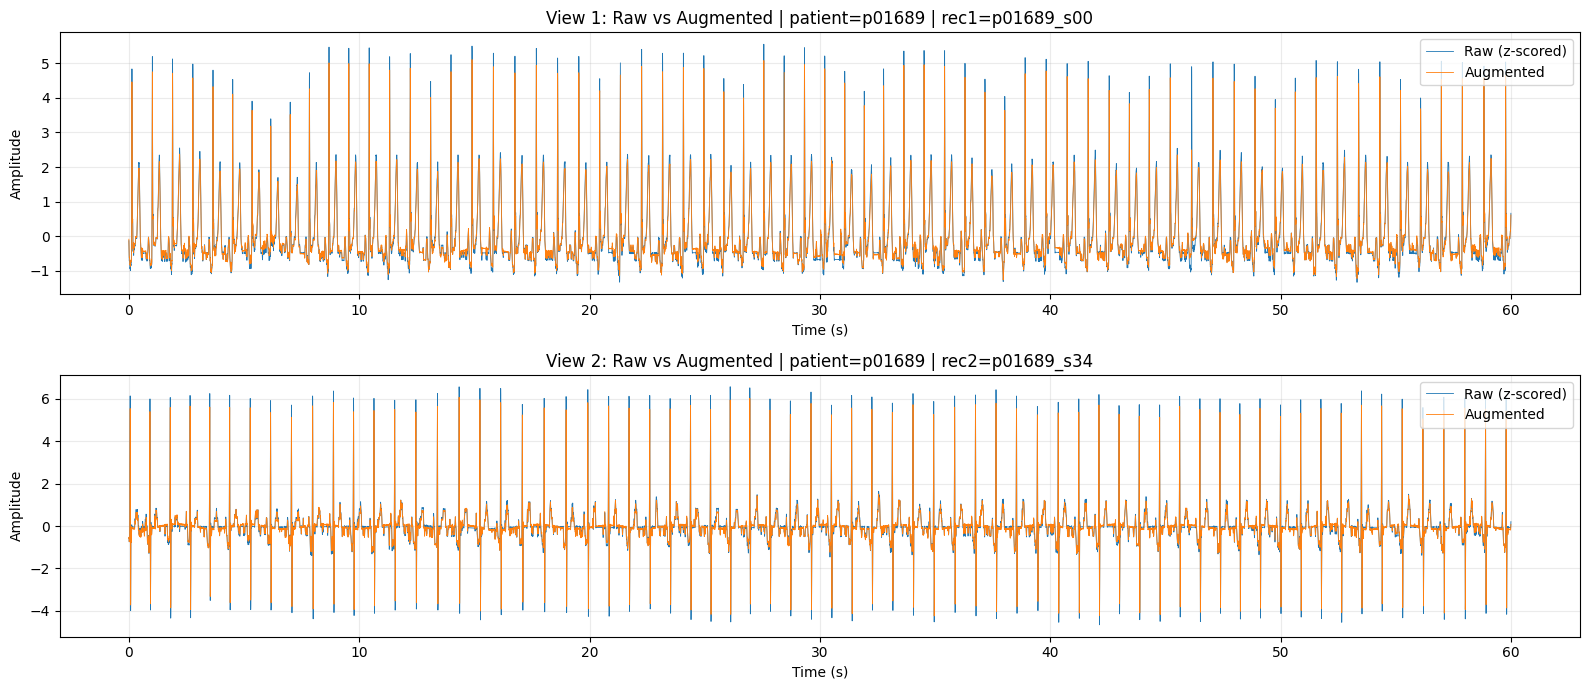

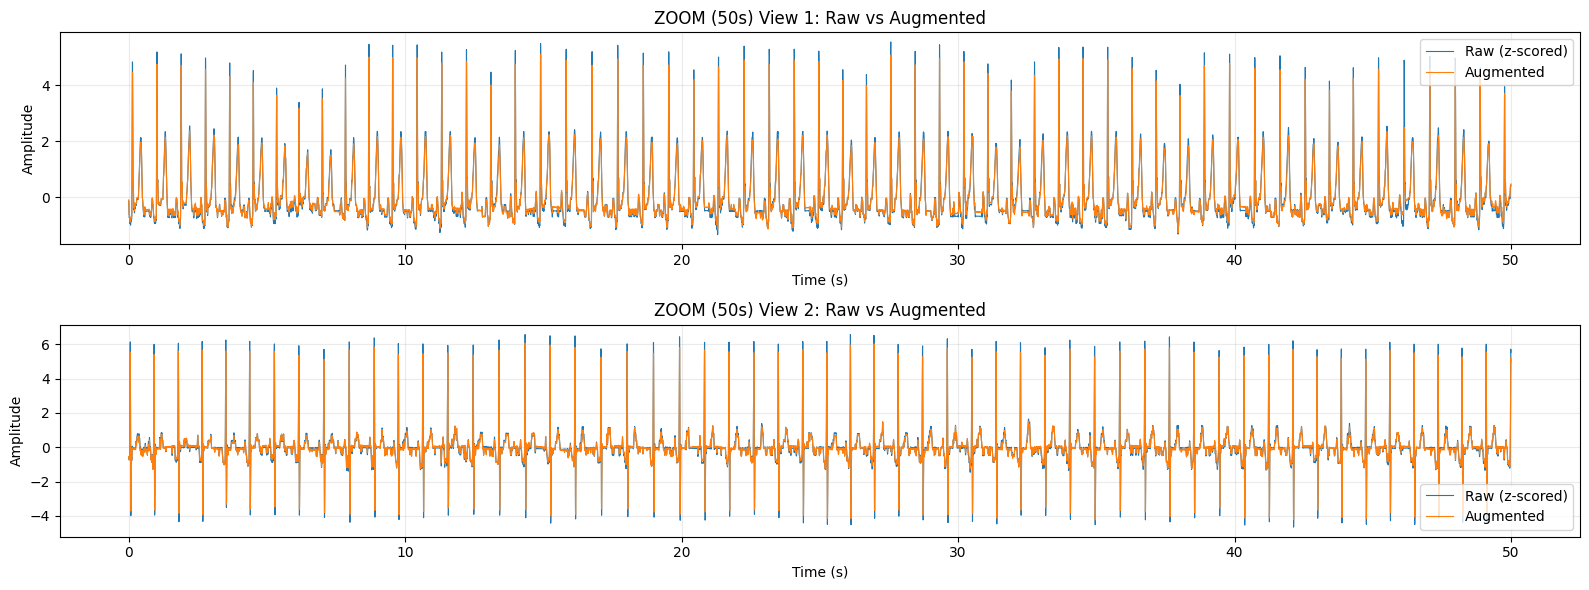

In [13]:
# --- Plot raw ECG vs augmented (same window) ---
# Assumes: FS, WINDOW_SAMPLES, ssl_ds, augment (ECGAugment), and wfdb/scipy already imported

import numpy as np
import matplotlib.pyplot as plt

def plot_raw_vs_augmented_from_ssl_ds(
    ssl_ds,
    fs=250,
    idx=None,
    zoom_sec=10,
    seed=0,
):
    """
    Plots:
      1) Raw window vs Augmented view (full 10-min)
      2) Zoomed-in overlay (first zoom_sec seconds) for morphology inspection

    Notes:
      - We temporarily disable augmentation inside ssl_ds to extract the TRUE raw windows,
        then apply augment outside to get the augmented versions.
      - Works for both same-record and cross-record datasets (keys rec/rec1/rec2).
    """
    rng = np.random.default_rng(seed)
    if idx is None:
        idx = int(rng.integers(0, len(ssl_ds)))

    # --- temporarily disable ds augmentation to get raw windows ---
    saved_aug = ssl_ds.augment
    ssl_ds.augment = None
    item = ssl_ds[idx]  # returns x1/x2 as raw (filtered) windows now
    ssl_ds.augment = saved_aug

    # Convert to numpy
    x1_raw = item["x1"].detach().cpu().numpy().astype(np.float32)
    x2_raw = item["x2"].detach().cpu().numpy().astype(np.float32)

    # Apply augmentation OUTSIDE (so we compare raw vs augmented)
    aug = saved_aug
    assert aug is not None, "ssl_ds.augment is None. Pass an augment or set ssl_ds.augment first."

    # Important: ECGAugment internally z-scores; to make a fair comparison we also z-score raw
    def zscore(x):
        return (x - x.mean()) / (x.std() + 1e-6)

    x1_raw_z = zscore(x1_raw)
    x2_raw_z = zscore(x2_raw)

    x1_aug = aug(x1_raw)  # returns augmented + internally z-scored
    x2_aug = aug(x2_raw)

    # Metadata
    pid = item.get("patient_id", "NA")
    rec1 = item.get("rec1", item.get("rec", "NA"))
    rec2 = item.get("rec2", item.get("rec", "NA"))

    # Time axes
    T = len(x1_raw_z)
    t = np.arange(T) / fs
    Z = int(min(T, zoom_sec * fs))
    tz = np.arange(Z) / fs

    # --- Figure: full window ---
    plt.figure(figsize=(16, 7))

    plt.subplot(2, 1, 1)
    plt.plot(t, x1_raw_z, linewidth=0.6, label="Raw (z-scored)")
    plt.plot(t, x1_aug,   linewidth=0.6, label="Augmented")
    plt.title(f"View 1: Raw vs Augmented | patient={pid} | rec1={rec1}")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.grid(alpha=0.25)
    plt.legend()

    plt.subplot(2, 1, 2)
    plt.plot(t, x2_raw_z, linewidth=0.6, label="Raw (z-scored)")
    plt.plot(t, x2_aug,   linewidth=0.6, label="Augmented")
    plt.title(f"View 2: Raw vs Augmented | patient={pid} | rec2={rec2}")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.grid(alpha=0.25)
    plt.legend()

    plt.tight_layout()
    plt.show()

    # --- Figure: zoomed morphology ---
    plt.figure(figsize=(16, 6))

    plt.subplot(2, 1, 1)
    plt.plot(tz, x1_raw_z[:Z], linewidth=0.8, label="Raw (z-scored)")
    plt.plot(tz, x1_aug[:Z],   linewidth=0.8, label="Augmented")
    plt.title(f"ZOOM ({zoom_sec}s) View 1: Raw vs Augmented")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.grid(alpha=0.25)
    plt.legend()

    plt.subplot(2, 1, 2)
    plt.plot(tz, x2_raw_z[:Z], linewidth=0.8, label="Raw (z-scored)")
    plt.plot(tz, x2_aug[:Z],   linewidth=0.8, label="Augmented")
    plt.title(f"ZOOM ({zoom_sec}s) View 2: Raw vs Augmented")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.grid(alpha=0.25)
    plt.legend()

    plt.tight_layout()
    plt.show()

# ---- Run it (random sample) ----
plot_raw_vs_augmented_from_ssl_ds(ssl_ds, fs=FS, idx=None, zoom_sec=50, seed=47)


In [14]:
import os
import numpy as np
import torch
from sklearn.cluster import MiniBatchKMeans

def build_offline_codebook_per_patient_window_z(
    patient_dirs,
    patch_len=160,
    n_tokens=256,
    patches_per_patient=36,
    window_samples=250 * 600,          # default = 10 minutes @250Hz; pass WINDOW_SAMPLES
    fs=250,
    seed=42,
    save_path="artifacts/icentia_codebook_256x160.pt",
    max_patients=None,                 # for quick debug runs
    bandpass=(0.5, 40.0),              # match your pipeline
    max_record_pick_tries=10,
    max_window_tries_per_patient=80,
    max_patch_tries_per_window=2000,
    std_thresh=1e-4,
):
    """
    For each patient:
      - choose ONE random record
      - load + bandpass filter whole record ONCE
      - repeat until you have patches_per_patient patches:
          * sample a random WINDOW (length window_samples)
          * window z-score (mean/std over that window)
          * sample random PATCHES (length patch_len) within that window
          * skip degenerate patches: NaNs or std < std_thresh
    Then fit MiniBatchKMeans on all patches.
    """
    import wfdb
    import scipy.signal

    rng = np.random.default_rng(seed)
    patient_dirs = list(patient_dirs)
    if max_patients is not None:
        patient_dirs = patient_dirs[: int(max_patients)]

    # --- bandpass filter once ---
    lowcut, highcut = bandpass
    nyq = 0.5 * fs
    b, a = scipy.signal.butter(4, [lowcut / nyq, highcut / nyq], btype="bandpass")

    patches_all = []
    n_pat_used = 0
    n_pat_skipped = 0

    for pi, pd in enumerate(patient_dirs):
        recs = list_record_bases(pd)
        if not recs:
            n_pat_skipped += 1
            continue

        # 1) choose ONE random record for this patient, load+filter once
        sig = None
        chosen_rec = None
        for _ in range(max_record_pick_tries):
            chosen_rec = recs[int(rng.integers(0, len(recs)))]
            try:
                x, _ = wfdb.rdsamp(str(chosen_rec))
                x = x[:, 0].astype(np.float32) if x.ndim == 2 else x.squeeze().astype(np.float32)
                x = scipy.signal.filtfilt(b, a, x).astype(np.float32)

                if len(x) < max(patch_len, window_samples):
                    continue
                if np.isnan(x).any() or float(np.std(x)) < std_thresh:
                    continue

                sig = x
                break
            except Exception:
                sig = None

        if sig is None:
            n_pat_skipped += 1
            continue

        sig_len = len(sig)
        if sig_len < window_samples:
            n_pat_skipped += 1
            continue

        # 2) collect patches_per_patient from windows within this same record
        pat_patches = []
        window_tries = 0

        while len(pat_patches) < patches_per_patient and window_tries < max_window_tries_per_patient:
            window_tries += 1

            # sample a random window
            ws = int(rng.integers(0, sig_len - window_samples))
            we = ws + window_samples
            win = sig[ws:we]

            if np.isnan(win).any():
                continue

            wstd = float(np.std(win))
            if wstd < std_thresh:
                continue

            # window z-score
            win = (win - float(np.mean(win))) / (wstd + 1e-6)
            win = win.astype(np.float32)

            # sample random patches inside this window
            # (we oversample attempts because we may skip degenerate patches)
            patch_tries = 0
            while (
                len(pat_patches) < patches_per_patient
                and patch_tries < max_patch_tries_per_window
            ):
                patch_tries += 1

                s = int(rng.integers(0, window_samples - patch_len))
                patch = win[s : s + patch_len]

                # skip degenerate patches
                if np.isnan(patch).any():
                    continue
                if float(np.std(patch)) < std_thresh:
                    continue

                pat_patches.append(patch)

        if len(pat_patches) < patches_per_patient:
            n_pat_skipped += 1
            continue

        patches_all.append(np.stack(pat_patches[:patches_per_patient], axis=0))  # [P, patch_len]
        n_pat_used += 1

        if (pi + 1) % 200 == 0:
            print(
                f"[{pi+1}/{len(patient_dirs)}] patients processed | "
                f"used={n_pat_used}, skipped={n_pat_skipped}, "
                f"patches={n_pat_used*patches_per_patient}"
            )

    if n_pat_used == 0:
        raise RuntimeError("No patients produced valid patches. Check paths / WFDB reads / thresholds.")

    X = np.concatenate(patches_all, axis=0)  # [n_pat_used*patches_per_patient, patch_len]
    print("Final patch matrix:", X.shape)

    km = MiniBatchKMeans(
        n_clusters=n_tokens,
        batch_size=4096,
        n_init=5,
        random_state=seed,
        reassignment_ratio=0.01,
    )
    km.fit(X)

    centroids = torch.from_numpy(km.cluster_centers_).float()

    payload = {
        "centroids": centroids,
        "meta": {
            "patch_len": int(patch_len),
            "n_tokens": int(n_tokens),
            "patches_per_patient": int(patches_per_patient),
            "window_samples": int(window_samples),
            "seed": int(seed),
            "fs": int(fs),
            "bandpass_low": float(lowcut),
            "bandpass_high": float(highcut),
            "std_thresh": float(std_thresh),
            "n_patients_requested": int(len(patient_dirs)),
            "n_patients_used": int(n_pat_used),
            "n_patients_skipped": int(n_pat_skipped),
            "n_patches_fit": int(X.shape[0]),
            "record_sampling": "one_random_record_per_patient",
            "sampling": "random_window_then_random_patch",
            "normalization": "window_zscore_then_patch",
        },
    }

    os.makedirs(os.path.dirname(save_path) or ".", exist_ok=True)
    torch.save(payload, save_path)

    return centroids


def load_offline_codebook(save_path="artifacts/icentia_codebook_256x160_1min.pt"):
    payload = torch.load(save_path, map_location="cpu")
    return payload["centroids"], payload.get("meta", {})


# ---- Build once ----
# centroids = build_offline_codebook_per_patient_window_z(
#     patient_dirs=ssl_patients,
#     patch_len=160,
#     n_tokens=256,
#     patches_per_patient=64,
#     window_samples=WINDOW_SAMPLES,  # IMPORTANT: window z-score happens on this window
#     fs=FS,
#     seed=42,
#     save_path="artifacts/icentia_codebook_256x160_1min.pt",
#     # max_patients=200,  # quick debug run
# )

# ---- Load later ----
centroids, meta = load_offline_codebook("artifacts/icentia_codebook_256x160_1min.pt")
print(centroids.shape)
print(meta)


[200/8800] patients processed | used=200, skipped=0, patches=12800
[400/8800] patients processed | used=400, skipped=0, patches=25600
[600/8800] patients processed | used=600, skipped=0, patches=38400
[800/8800] patients processed | used=800, skipped=0, patches=51200
[1000/8800] patients processed | used=1000, skipped=0, patches=64000
[1200/8800] patients processed | used=1200, skipped=0, patches=76800
[1400/8800] patients processed | used=1400, skipped=0, patches=89600
[1600/8800] patients processed | used=1600, skipped=0, patches=102400
[1800/8800] patients processed | used=1800, skipped=0, patches=115200
[2000/8800] patients processed | used=2000, skipped=0, patches=128000
[2200/8800] patients processed | used=2200, skipped=0, patches=140800
[2400/8800] patients processed | used=2400, skipped=0, patches=153600
[2600/8800] patients processed | used=2600, skipped=0, patches=166400
[2800/8800] patients processed | used=2800, skipped=0, patches=179200
[3000/8800] patients processed | us

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# -------------------------
# Tokenizer A: Quantization Based
# -------------------------

class KMeansVQPatchTokenizer(nn.Module):
    """
    Vector-quantize each patch using a fixed KMeans codebook.

    Inputs:
      x: [B, T] window (typically already z-scored by your pipeline, but we can enforce it)

    Output:
      tok: [B, L, d_model] token embeddings
      (optionally ids: [B, L])
    """
    def __init__(
        self,
        d_model: int,
        centroids: torch.Tensor,     # [K, patch_len]
        patch_len: int = 160,
        enforce_window_zscore: bool = True,
        use_embedding_table: bool = True,
        return_ids: bool = False,
    ):
        super().__init__()
        assert centroids.ndim == 2, "centroids must be [K, patch_len]"
        K, P = centroids.shape
        assert P == patch_len, f"centroids patch_len ({P}) != patch_len ({patch_len})"

        self.patch_len = int(patch_len)
        self.K = int(K)
        self.enforce_window_zscore = bool(enforce_window_zscore)
        self.use_embedding_table = bool(use_embedding_table)
        self.return_ids = bool(return_ids)

        # Register codebook as a buffer (no gradients)
        self.register_buffer("centroids", centroids.float().contiguous())  # [K, P]

        if self.use_embedding_table:
            # Token embedding lookup (learnable, like NLP)
            self.embed = nn.Embedding(self.K, d_model)
        else:
            # Use centroid waveform itself then project to d_model (non-learnable codebook, learnable projection)
            self.proj = nn.Linear(self.patch_len, d_model, bias=True)

    @staticmethod
    def _window_zscore(x: torch.Tensor) -> torch.Tensor:
        # x: [B, T]
        mean = x.mean(dim=1, keepdim=True)
        std = x.std(dim=1, keepdim=True).clamp_min(1e-6)
        return (x - mean) / std

    def forward(self, x: torch.Tensor):
        # x: [B, T]
        B, T = x.shape
        L = T // self.patch_len
        if L <= 0:
            raise ValueError(f"Input length T={T} smaller than patch_len={self.patch_len}")

        x = x[:, : L * self.patch_len]                      # [B, L*P]
        if self.enforce_window_zscore:
            x = self._window_zscore(x)

        patches = x.view(B, L, self.patch_len)              # [B, L, P]

        # Nearest-centroid assignment (Euclidean)
        # torch.cdist is convenient and reasonably fast for your sizes (B*L ~ 32*2*937)
        # distances: [B, L, K]
        d = torch.cdist(patches, self.centroids.unsqueeze(0), p=2)  # [B, L, K]
        ids = d.argmin(dim=-1)                                      # [B, L]

        if self.use_embedding_table:
            tok = self.embed(ids)                                   # [B, L, d_model]
        else:
            # Use centroid waveforms and project
            q = self.centroids[ids]                                 # [B, L, P]
            tok = self.proj(q)                                      # [B, L, d_model]

        if self.return_ids:
            return tok, ids
        return tok



# -------------------------
# Tokenizer B: Conv1d patch embedding
# -------------------------
class ConvPatchTokenizer(nn.Module):
    def __init__(self, d_model: int, patch_len: int = 160):
        super().__init__()
        self.patch_len = patch_len
        self.conv = nn.Conv1d(1, d_model, kernel_size=patch_len, stride=patch_len)

    def forward(self, x):  # x: [B, T]
        x = x.unsqueeze(1)  # [B, 1, T]
        tok = self.conv(x)  # [B, d_model, L]
        tok = tok.transpose(1, 2)  # [B, L, d_model]
        return tok


# -------------------------
# Transformer encoder + contrastive head
# -------------------------

class ECGEncoder(nn.Module):
    def __init__(
        self,
        tokenizer: nn.Module,
        d_model=256,
        n_layers=6,
        n_heads=8,
        dropout=0.1,
        proj_dim=128,
        max_len=1024,          # set based on (WINDOW_SAMPLES // patch_len)
        use_cls=False,         # False => mean pooling
    ):
        super().__init__()
        self.tokenizer = tokenizer
        self.use_cls = use_cls

        # +1 for CLS if used
        self.pos_embed = nn.Parameter(torch.zeros(1, max_len + (1 if use_cls else 0), d_model))

        if use_cls:
            self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        else:
            self.cls_token = None

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=4 * d_model,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
            norm_first=True,
        )
        self.tr = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        self.norm = nn.LayerNorm(d_model)
        self.proj = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Linear(d_model, proj_dim),
        )

        # init
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        if self.cls_token is not None:
            nn.init.trunc_normal_(self.cls_token, std=0.02)

    def forward(self, x, return_h = False):  # x: [B, T]
        tok = self.tokenizer(x)  # [B, L, d_model]
        B, L, D = tok.shape

        if self.use_cls:
            cls = self.cls_token.expand(B, -1, -1)      # [B, 1, D]
            tok = torch.cat([cls, tok], dim=1)          # [B, 1+L, D]
            tok = tok + self.pos_embed[:, : (L + 1), :]
        else:
            tok = tok + self.pos_embed[:, :L, :]

        z = self.tr(tok)          # [B, L(+1), D]
        z = self.norm(z)

        if self.use_cls:
            h = z[:, 0]           # CLS
        else:
            h = z.mean(dim=1)     # mean pooling over tokens

        y = self.proj(h)
        y = F.normalize(y, dim=-1)

        if return_h:
            return h, y
        return y



def info_nce(z, pair_ids, temperature=0.1):
    z = z.float()  # important under autocast
    sim = ((z @ z.T) / temperature).float()

    N = z.size(0)
    mask = torch.eye(N, device=z.device, dtype=torch.bool)
    sim = sim.masked_fill(mask, torch.finfo(sim.dtype).min)

    pid = pair_ids
    pos = (pid.unsqueeze(0) == pid.unsqueeze(1)) & (~mask)

    logsumexp = torch.logsumexp(sim, dim=1)
    pos_sim = sim[pos].view(N)
    return -(pos_sim - logsumexp).mean()


In [16]:
import math
import time
import torch
from torch.cuda.amp import autocast, GradScaler
import matplotlib.pyplot as plt
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def cosine_lr(step, total_steps, lr_max, lr_min=1e-5, warmup_steps=200):
    if warmup_steps > 0 and step < warmup_steps:
        return lr_max * step / max(1, warmup_steps)
    t = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    t = min(max(t, 0.0), 1.0)
    return lr_min + 0.5 * (lr_max - lr_min) * (1 + math.cos(math.pi * t))

def train_ssl(
    model, loader,
    epochs=1,
    lr=3e-4,
    wd=0.05,
    temperature=0.1,
    max_steps=None,
    log_every=20,
    grad_clip=1.0,
    warmup_steps=200,
    lr_min=1e-5,
    use_cosine=True,
    exp_dir=None,
):
    model.to(device).train()

    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd, fused=(device.type=="cuda"))
    scaler = GradScaler(enabled=(device.type == "cuda"))

    losses, lrs, grad_norms, step_times = [], [], [], []
    step = 0

    if max_steps is None:
        max_steps = epochs * len(loader)  # default: run full epochs

    for ep in range(epochs):
        for batch in loader:
            if step >= max_steps:
                return {"losses": losses, "lrs": lrs, "grad_norms": grad_norms, "step_times": step_times}

            t0 = time.time()

            x = batch["x"].to(device, non_blocking=True).float()
            pair_ids = batch["pair_ids"].to(device, non_blocking=True)

            # per-step LR schedule
            if use_cosine:
                cur_lr = cosine_lr(step, max_steps, lr_max=lr, lr_min=lr_min, warmup_steps=warmup_steps)
                for pg in opt.param_groups:
                    pg["lr"] = cur_lr
            else:
                cur_lr = opt.param_groups[0]["lr"]

            opt.zero_grad(set_to_none=True)

            with autocast(enabled=(device.type == "cuda")):
                z = model(x)  # [2B, D]
                loss = info_nce(z, pair_ids, temperature=temperature)

            scaler.scale(loss).backward()
            scaler.unscale_(opt)

            gnorm = torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip) if grad_clip else 0.0

            scaler.step(opt)
            scaler.update()

            losses.append(float(loss.detach().cpu()))
            lrs.append(float(cur_lr))
            grad_norms.append(float(gnorm.detach().cpu()) if torch.is_tensor(gnorm) else float(gnorm))
            step_times.append(time.time() - t0)

            if step % log_every == 0:
                views_per_sec = x.size(0) / max(step_times[-1], 1e-9)  # x is [2B, T]
                print(f"ep={ep} step={step} loss={losses[-1]:.4f} lr={cur_lr:.2e} gnorm={grad_norms[-1]:.2f} views/s={views_per_sec:.1f}")

            step += 1
            # Every 1000 steps, save a backup
            if exp_dir and step % 1000 == 0:
                checkpoint_path = os.path.join(exp_dir, f"checkpoint_{step}.pth")
                torch.save({
                    'step': step,
                    'model_state_dict': model.state_dict(),
                    'opt_state_dict': opt.state_dict(),
                    'loss': losses[-1],
                }, checkpoint_path)
                print(f"--- Checkpoint saved at step {step} ---")

    return {"losses": losses, "lrs": lrs, "grad_norms": grad_norms, "step_times": step_times}

def plot_loss(losses, title="SSL loss"):
    plt.figure()
    plt.plot(losses)
    plt.xlabel("Step")
    plt.ylabel("InfoNCE loss")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.show()


/tmp/ipykernel_144944/410188173.py:142: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.tr = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
/tmp/ipykernel_144944/2731639155.py:34: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=(device.type == "cuda"))
/tmp/ipykernel_144944/2731639155.py:62: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type == "cuda")):


ep=0 step=0 loss=3.6116 lr=0.00e+00 gnorm=5.28 views/s=97.8
ep=0 step=20 loss=3.9120 lr=3.00e-05 gnorm=6.46 views/s=3163.8
ep=0 step=40 loss=2.8847 lr=6.00e-05 gnorm=4.47 views/s=5521.8
ep=0 step=60 loss=3.6492 lr=9.00e-05 gnorm=5.19 views/s=5846.2
ep=0 step=80 loss=3.3542 lr=1.20e-04 gnorm=3.90 views/s=4365.6
ep=0 step=100 loss=3.2024 lr=1.50e-04 gnorm=4.30 views/s=4220.0
ep=0 step=120 loss=3.8981 lr=1.80e-04 gnorm=4.96 views/s=5688.8
ep=0 step=140 loss=3.1920 lr=2.10e-04 gnorm=3.44 views/s=5444.9
ep=0 step=160 loss=3.0003 lr=2.40e-04 gnorm=3.58 views/s=2543.9
ep=0 step=180 loss=3.0350 lr=2.70e-04 gnorm=3.94 views/s=5328.8
ep=0 step=200 loss=2.8981 lr=3.00e-04 gnorm=2.88 views/s=4662.2
ep=0 step=220 loss=3.5413 lr=3.00e-04 gnorm=2.53 views/s=4095.1
ep=0 step=240 loss=3.5107 lr=3.00e-04 gnorm=3.43 views/s=4366.2
ep=0 step=260 loss=3.5284 lr=3.00e-04 gnorm=3.02 views/s=4596.7
ep=1 step=280 loss=2.6282 lr=3.00e-04 gnorm=3.17 views/s=5848.0
ep=1 step=300 loss=3.3070 lr=3.00e-04 gnorm=3.20

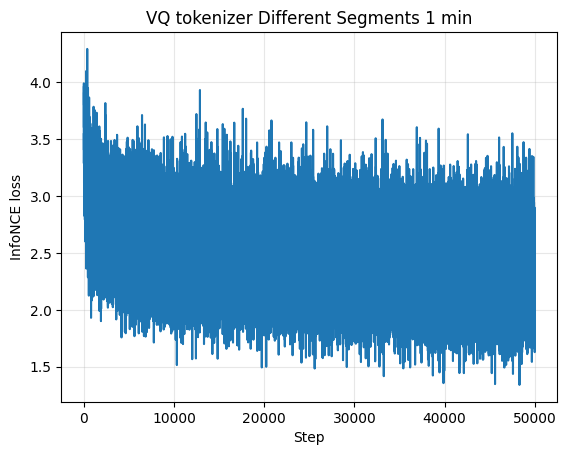

In [17]:
patch_len = 160
# max_len = 1024  # 937
max_len = (WINDOW_SAMPLES // patch_len) + 2
exp_dir = "VQ_tokenizer_1min"
os.makedirs(exp_dir, exist_ok=True)

tok_vq = KMeansVQPatchTokenizer(
    d_model=256,
    centroids=centroids,
    patch_len=patch_len,
    enforce_window_zscore=False,
    use_embedding_table=True,
    return_ids=False,
)

model_vq = ECGEncoder(tokenizer=tok_vq, d_model=256, max_len=max_len, use_cls=False)

stats = train_ssl(model_vq, ssl_loader, epochs=200, max_steps=50000, exp_dir=exp_dir) 
plot_loss(stats["losses"], title="VQ tokenizer Different Segments 1 min")

/tmp/ipykernel_144944/410188173.py:142: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.tr = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
/tmp/ipykernel_144944/2731639155.py:34: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=(device.type == "cuda"))
/tmp/ipykernel_144944/2731639155.py:62: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type == "cuda")):


ep=0 step=0 loss=4.7705 lr=0.00e+00 gnorm=19.71 views/s=675.7
ep=0 step=20 loss=4.0714 lr=3.00e-05 gnorm=3.20 views/s=3529.1
ep=0 step=40 loss=3.8483 lr=6.00e-05 gnorm=3.16 views/s=5631.2
ep=0 step=60 loss=3.6379 lr=9.00e-05 gnorm=4.51 views/s=3662.1
ep=0 step=80 loss=3.7029 lr=1.20e-04 gnorm=7.22 views/s=5201.2
ep=0 step=100 loss=3.1597 lr=1.50e-04 gnorm=6.45 views/s=3612.4
ep=0 step=120 loss=3.1004 lr=1.80e-04 gnorm=6.71 views/s=3679.2
ep=0 step=140 loss=3.9660 lr=2.10e-04 gnorm=10.98 views/s=5474.3
ep=0 step=160 loss=2.5710 lr=2.40e-04 gnorm=5.81 views/s=2849.3
ep=0 step=180 loss=2.4505 lr=2.70e-04 gnorm=5.29 views/s=5524.0
ep=0 step=200 loss=1.9673 lr=3.00e-04 gnorm=5.29 views/s=4188.2
ep=0 step=220 loss=2.3083 lr=3.00e-04 gnorm=5.53 views/s=3004.4
ep=0 step=240 loss=2.4854 lr=3.00e-04 gnorm=6.08 views/s=4770.2
ep=0 step=260 loss=2.3914 lr=3.00e-04 gnorm=5.95 views/s=4908.8
ep=1 step=280 loss=2.6483 lr=3.00e-04 gnorm=6.45 views/s=4809.3
ep=1 step=300 loss=2.6290 lr=3.00e-04 gnorm=4

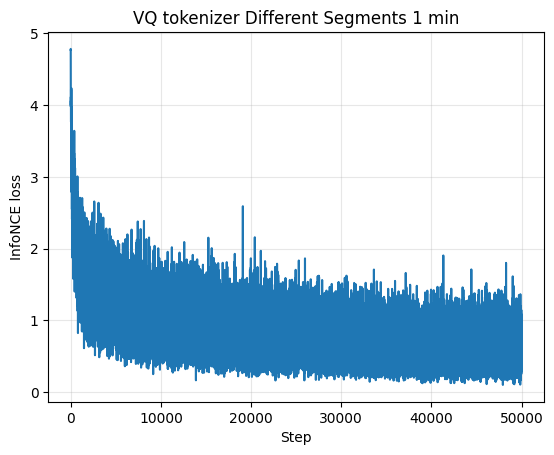

In [18]:
### This training is with different segments ###

exp_dir = "CNN_tokenizer_1min"
os.makedirs(exp_dir, exist_ok=True)

tok_c = ConvPatchTokenizer(d_model=256, patch_len=patch_len)
model_c = ECGEncoder(tokenizer=tok_c, d_model=256, max_len=max_len, use_cls=False)

stats = train_ssl(model_c, ssl_loader, epochs=200, max_steps=50000, exp_dir=exp_dir)
plot_loss(stats["losses"], title="VQ tokenizer Different Segments 1 min")

### Test Convergence

In [19]:
import os, glob, re
import numpy as np
import torch
import torch.nn.functional as F
from tqdm import tqdm

# -------------------------
# 1) Deterministic probe dataset (patient -> K windows)
# -------------------------
class DeterministicPatientWindows(torch.utils.data.Dataset):
    def __init__(self, patient_dirs, window_samples, fs=250, seed=1234, k_windows=3, cache_size=64):
        self.patient_dirs = list(patient_dirs)
        self.window_samples = int(window_samples)
        self.fs = fs
        self.seed = int(seed)
        self.k_windows = int(k_windows)

        self.patient_records = [list_record_bases(pd) for pd in self.patient_dirs]

        self._cache_size = int(cache_size)
        self._init_record_cache()

    def __len__(self):
        return len(self.patient_dirs)

    def _init_record_cache(self):
        import scipy.signal, wfdb
        from functools import lru_cache

        lowcut = 0.5
        highcut = 40.0
        nyq = 0.5 * self.fs
        b, a = scipy.signal.butter(4, [lowcut/nyq, highcut/nyq], btype="bandpass")

        @lru_cache(maxsize=self._cache_size)
        def _cached_load(rec_base_str: str):
            sig, _ = wfdb.rdsamp(rec_base_str)
            sig = sig[:, 0].astype(np.float32) if sig.ndim == 2 else sig.squeeze().astype(np.float32)
            sig = scipy.signal.filtfilt(b, a, sig).astype(np.float32)
            return sig

        self._load_record_cached = _cached_load

    def _sample_window(self, sig, rng, max_tries=200):
        sig_len = len(sig)
        if sig_len <= self.window_samples:
            return None
        for _ in range(max_tries):
            s = int(rng.integers(0, sig_len - self.window_samples))
            e = s + self.window_samples
            x = sig[s:e]
            if np.isnan(x).any() or np.std(x) < 1e-4:
                continue
            x = (x - x.mean()) / (x.std() + 1e-6)
            return x.astype(np.float32)
        return None

    def __getitem__(self, idx):
        recs = self.patient_records[idx]
        pid = self.patient_dirs[idx].name

        # deterministic rng per patient
        rng_p = np.random.default_rng(self.seed + 1000003 * int(idx))

        if not recs:
            # deterministic fallback: zeros
            x0 = np.zeros((self.window_samples,), dtype=np.float32)
            xk = np.stack([x0]*self.k_windows, axis=0)
            return {"patient_id": pid, "x": torch.from_numpy(xk)}

        # choose records deterministically
        K = self.k_windows
        chosen = rng_p.choice(len(recs), size=K, replace=(len(recs) < K))

        xs = []
        for wi, j in enumerate(chosen):
            rng_w = np.random.default_rng(self.seed + 1000003 * int(idx) + 9176 * int(wi))
            rec_path = recs[int(j)]
            sig = self._load_record_cached(str(rec_path))
            x = self._sample_window(sig, rng_w)
            if x is None:
                x = np.zeros((self.window_samples,), dtype=np.float32)
            xs.append(torch.from_numpy(x))

        return {"patient_id": pid, "x": torch.stack(xs, dim=0)}  # [K, T]


def collate_patient_windows(batch):
    xs, pids = [], []
    for item in batch:
        xk = item["x"]  # [K, T]
        xs.append(xk)
        pids.extend([item["patient_id"]] * xk.size(0))
    x = torch.cat(xs, dim=0)  # [B*K, T]
    return {"x": x, "patient_ids": pids}


# -------------------------
# 2) Retrieval metric (Recall@K)
# -------------------------
def recall_at_k(emb, labels, ks=(1,5,10)):
    # emb: [N, D], labels: list/array length N
    emb = torch.from_numpy(emb)
    emb = F.normalize(emb, dim=1)
    sim = (emb @ emb.T).cpu().numpy()
    np.fill_diagonal(sim, -1e9)

    labels = np.asarray(labels)
    out = {}
    order = np.argsort(-sim, axis=1)  # descending
    for k in ks:
        topk = order[:, :k]
        hit = (labels[topk] == labels[:, None]).any(axis=1).mean()
        out[f"R@{k}"] = float(hit)
    return out


@torch.no_grad()
def embed_probe_set(model, probe_loader, device):
    model.eval()
    H, pid = [], []
    for batch in probe_loader:
        x = batch["x"].to(device, non_blocking=True).float()
        h, _ = model(x, return_h=True)          # h: [M, d_model]
        H.append(h.detach().cpu().numpy())
        pid.extend(batch["patient_ids"])
    H = np.concatenate(H, axis=0)
    return H, np.array(pid)


# -------------------------
# 3) Checkpoint sweep
# -------------------------
def list_checkpoints(exp_dir):
    # expects checkpoint_1000.pth, checkpoint_2000.pth, ...
    cks = glob.glob(os.path.join(exp_dir, "checkpoint_*.pth"))
    def step_of(p):
        m = re.search(r"checkpoint_(\d+)\.pth", os.path.basename(p))
        return int(m.group(1)) if m else -1
    cks = sorted(cks, key=step_of)
    return [(step_of(p), p) for p in cks if step_of(p) >= 0]

def sweep_convergence(exp_dir, make_model_fn, probe_loader, device, ks=(1,5,10), max_ckpts=None):
    rows = []
    ckpts = list_checkpoints(exp_dir)
    if max_ckpts is not None:
        ckpts = ckpts[:max_ckpts]

    for step, path in tqdm(ckpts, desc=f"Sweeping {exp_dir}"):
        model = make_model_fn().to(device)
        ckpt = torch.load(path, map_location=device)
        model.load_state_dict(ckpt["model_state_dict"], strict=True)

        H, pid = embed_probe_set(model, probe_loader, device)
        # use integer labels for retrieval
        uniq = sorted(set(pid.tolist()))
        pid2i = {p:i for i,p in enumerate(uniq)}
        lab = np.array([pid2i[p] for p in pid], dtype=np.int64)

        r = recall_at_k(H, lab, ks=ks)
        rows.append({"step": step, **r})
    return rows


In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# fixed probe set (use same for both sweeps)
probe_ds = DeterministicPatientWindows(
    patient_dirs=test_patients,         # or patient_subset of size 550
    window_samples=WINDOW_SAMPLES,
    fs=FS,
    seed=1234,
    k_windows=3,                        # start with 3; later bump to 5 if you want
    cache_size=64
)
probe_loader = DataLoader(
    probe_ds, batch_size=8, shuffle=False, num_workers=0,
    collate_fn=collate_patient_windows, pin_memory=True
)

patch_len = 160
max_len = (WINDOW_SAMPLES // patch_len) + 2

def make_cnn():
    tok = ConvPatchTokenizer(d_model=256, patch_len=patch_len)
    return ECGEncoder(tokenizer=tok, d_model=256, max_len=max_len, use_cls=False)

def make_vq():
    tok = KMeansVQPatchTokenizer(
        d_model=256, centroids=centroids, patch_len=patch_len,
        enforce_window_zscore=False, use_embedding_table=True, return_ids=False
    )
    return ECGEncoder(tokenizer=tok, d_model=256, max_len=max_len, use_cls=False)

cnn_rows = sweep_convergence("CNN_tokenizer_1min", make_cnn, probe_loader, device)
vq_rows  = sweep_convergence("VQ_tokenizer_1min",  make_vq,  probe_loader, device)

print(cnn_rows[-1], vq_rows[-1])


Sweeping CNN_tokenizer_1min:   0%|          | 0/50 [00:00<?, ?it/s]/tmp/ipykernel_144944/410188173.py:142: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.tr = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
Sweeping VQ_tokenizer_1min: 100%|██████████| 50/50 [22:56<00:00, 27.53s/it]

{'step': 50000, 'R@1': 0.7654545454545455, 'R@5': 0.8763636363636363, 'R@10': 0.9109090909090909} {'step': 50000, 'R@1': 0.12606060606060607, 'R@5': 0.28909090909090907, 'R@10': 0.38545454545454544}


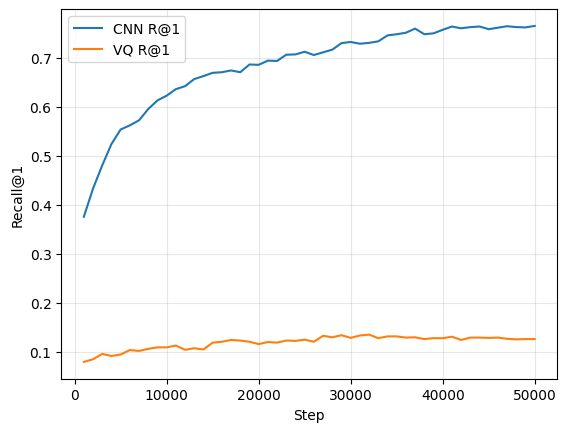

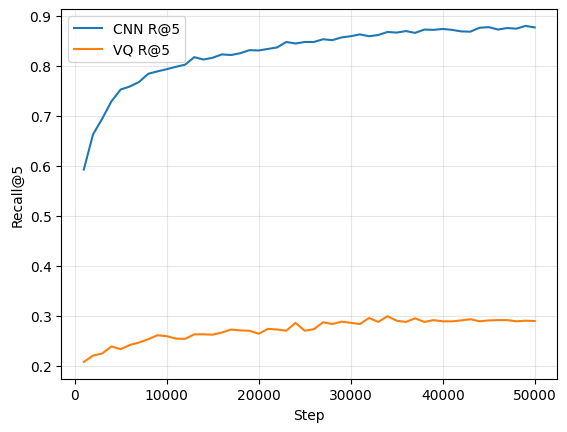

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

cnn_df = pd.DataFrame(cnn_rows)
vq_df  = pd.DataFrame(vq_rows)

plt.figure()
plt.plot(cnn_df["step"], cnn_df["R@1"], label="CNN R@1")
plt.plot(vq_df["step"],  vq_df["R@1"],  label="VQ R@1")
plt.xlabel("Step"); plt.ylabel("Recall@1"); plt.grid(alpha=0.3); plt.legend(); plt.show()

plt.figure()
plt.plot(cnn_df["step"], cnn_df["R@5"], label="CNN R@5")
plt.plot(vq_df["step"],  vq_df["R@5"],  label="VQ R@5")
plt.xlabel("Step"); plt.ylabel("Recall@5"); plt.grid(alpha=0.3); plt.legend(); plt.show()
